# 1. Imports

In [1]:
import os
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

# 2. Alle gesegmenteerde hoesten inladen

In [2]:
SOUNDS_DIR = "data/sounds/sounds"

X = []
wav_paths = []

for candidate in os.listdir(SOUNDS_DIR):
    seg_folder = os.path.join(SOUNDS_DIR, candidate, "cough_segmented")
    if not os.path.exists(seg_folder):
        continue

    for fname in os.listdir(seg_folder):
        if not fname.endswith("_processed.wav"):
            continue

        fp = os.path.join(seg_folder, fname)
        y, sr = librosa.load(fp, sr=16000)

        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, n_fft=2048, hop_length=512)
        mel_db = librosa.power_to_db(mel, ref=np.max)

        mel_min = mel_db.min()
        mel_max = mel_db.max()
        mel_norm = (mel_db - mel_min) / (mel_max - mel_min + 1e-8)

        if mel_norm.shape[1] < 128:
            pad = np.zeros((64, 128 - mel_norm.shape[1]))
            mel_norm = np.hstack([mel_norm, pad])
        else:
            mel_norm = mel_norm[:, :128]

        X.append(mel_norm)
        wav_paths.append(fp)

X = np.array(X, dtype=np.float32)[..., np.newaxis]
print("Dataset shape:", X.shape)
print("Aantal hoesten:", len(X))

c:\Users\briek\.virtualenvs\Deep_learning_project-8qJO88P_\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset shape: (13323, 64, 128, 1)
Aantal hoesten: 13323


# 3. VAE bouwen

In [ ]:
latent_dim = 16

input_img = layers.Input(shape=(64, 128, 1))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Flatten()(x)

z_mean    = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

class SamplingLayer(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        z = z_mean + tf.exp(0.5 * z_log_var) * eps
        kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        self.add_loss(0.001 * kl_loss)

        return z

z = SamplingLayer()([z_mean, z_log_var])

encoder = Model(input_img, z)

Encoder klaar


# 4. Decoder

In [42]:
latent_input = layers.Input(shape=(latent_dim,))

x = layers.Dense(8 * 16 * 8, activation='relu')(latent_input)
x = layers.Reshape((8, 16, 8))(x)

x = layers.Conv2DTranspose(16, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2DTranspose(1, (3, 3), activation='linear', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Activation('sigmoid')(x) 

decoder = Model(latent_input, x)
print("Decoder output shape:", decoder.output_shape)

Decoder output shape: (None, 64, 128, 1)


# 5. VAE trainen

Epoch 1/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - loss: 0.0101 - val_loss: 0.0048
Epoch 2/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - loss: 0.0041 - val_loss: 0.0041
Epoch 3/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - loss: 0.0037 - val_loss: 0.0038
Epoch 4/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - loss: 0.0034 - val_loss: 0.0035
Epoch 5/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - loss: 0.0032 - val_loss: 0.0034
Epoch 6/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - loss: 0.0031 - val_loss: 0.0033
Epoch 7/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - loss: 0.0031 - val_loss: 0.0032
Epoch 8/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - loss: 0.0030 - val_loss: 0.0032
Epoch 9/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - loss: 0.0030 - val_loss: 0.0033
Epoch 10/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - loss: 0.0030 - val_loss: 0.0031
Epoch 11/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - loss: 0.0029 - val_loss: 0.0031
Epoch 12/100
750/75

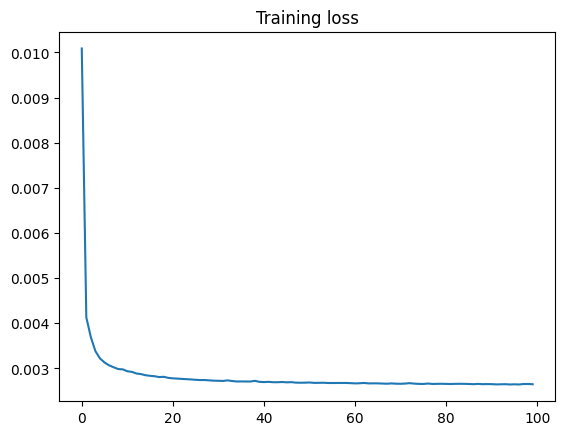

In [43]:
vae_input = layers.Input(shape=(64, 128, 1))
z = encoder(vae_input)
vae_output = decoder(z)

vae = Model(vae_input, vae_output)
vae.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse'
)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = vae.fit(
    X, X,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stopping]
)

plt.plot(history.history['loss'])
plt.title('Training loss')
plt.show()

## 5.1 Save decoder

In [52]:
decoder.save("decoder_model.keras")

# 6. Samplen uit de latent space

## 6.1 Laad decoder

In [2]:
from tensorflow.keras.models import load_model

decoder = load_model("models/decoder/decoder_model.keras")
latent_dim = 16

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


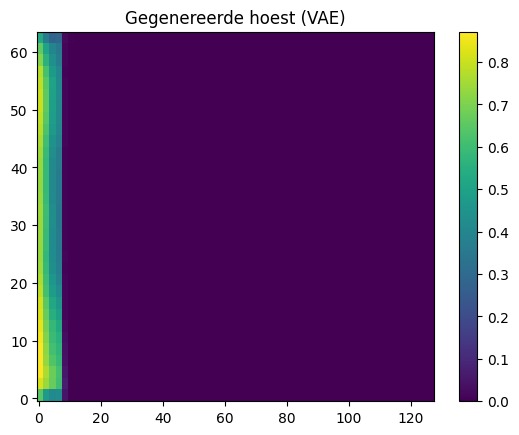

In [ ]:
random_z = np.random.normal(0, 1, (1, latent_dim)).astype(np.float32)

generated_mel = decoder.predict(random_z)[0, :, :, 0]

plt.imshow(generated_mel)
plt.title('Gegenereerde hoest (VAE)')
plt.colorbar()
plt.show()

# 7. Naar wav

In [ ]:
import librosa
import soundfile as sf
import numpy as np
import glob

files = glob.glob("data/sounds/sounds/*/cough_segmented/*_processed.wav")
ref_wav_pad = files[0]

echte_wav, sr = librosa.load(ref_wav_pad, sr=16000)
D_orig = librosa.stft(echte_wav, n_fft=2048, hop_length=512)
fase_orig = np.angle(D_orig)

mel_power = librosa.db_to_power(generated_mel * 80 - 80)
mel_filters = librosa.filters.mel(sr=16000, n_fft=2048, n_mels=64)
stft_matrix = np.dot(mel_filters.T, mel_power)

min_frames = min(stft_matrix.shape[1], fase_orig.shape[1])
stft_matrix = stft_matrix[:, :min_frames]
fase_orig_cut = fase_orig[:, :min_frames]

audio = librosa.istft(stft_matrix * np.exp(1j * fase_orig_cut), hop_length=512)
audio = audio / (np.max(np.abs(audio)) + 1e-8)


sf.write("generated/vae_cough.wav", audio, 16000)